# Module 2 — Classification Modeling (Accident Severity Prediction)

**Project:** Traffic Accident Severity Prediction — US Accidents (2016–2023)
**DAP391m (AI & Data Science with Python & SQL) | Fall 2026 — Lớp AI2003**
**Nhóm:** Group 7 — Lê Huy Hùng (SE204967) · Nguyễn Thiện Nhân (SE203924) · Đặng Gia Bảo (SE203977)
**Giảng viên:** Lê Nhật Tùng

---

### Mục tiêu (RQ1 · RQ2 · RQ3)
Xây dựng và so sánh các mô hình phân loại để **dự báo mức độ nghiêm trọng của tai nạn** (`Severity` 1–4, multi-class), xác định mô hình nào chính xác nhất trên tập dữ liệu lớn (~7.7 triệu dòng), và trả lời RQ1: **điều kiện nào (thời tiết, thời điểm, hạ tầng đường, tầm nhìn) liên quan mạnh nhất tới tai nạn nghiêm trọng**, và RQ3: **bản đồ hotspot dự đoán từ mô hình trùng khớp với tai nạn thực tế bao nhiêu %, so với thống kê lịch sử đơn thuần**.

> **Input:** `cleaned_us_accidents.csv` (output Bước 2 — Data Preparation & SQL nâng cao; dữ liệu gốc: Kaggle, Sobhan Moosavi, CC BY-NC-SA 4.0)
> **Target:** `Severity` (1–4, multi-class) → bài toán **classification**
> **Model:** 3 gradient boosting — **XGBoost · LightGBM · HistGradientBoosting (sklearn)**
>

## 0. Môi trường

Chạy cell dưới **một lần** nếu chưa có thư viện. Lưu ý phiên bản: `xgboost>=2.0` (API mới: `device=`, `early_stopping_rounds` trong constructor). HistGradientBoosting nằm sẵn trong `scikit-learn` (>=1.1), không cần cài thêm.

In [1]:
import xgboost, lightgbm, sklearn
print('xgboost  :', xgboost.__version__)   # dùng sklearn estimator API hiện hành
print('lightgbm :', lightgbm.__version__)
print('sklearn  :', sklearn.__version__)   # HistGradientBoosting cần >= 1.1

xgboost  : 3.2.0
lightgbm : 4.7.0
sklearn  : 1.8.0


## 1. Setup & Load dữ liệu đã làm sạch

Đọc trực tiếp `cleaned_us_accidents.csv`

In [2]:
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'
RANDOM_STATE = 42
df = pd.read_csv('cleaned_us_accidents.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')


Loaded: 7,728,394 rows x 52 columns


## 2. Feature Engineering & chống Data Leakage

### Lưu ý quan trọng về Data Leakage
Một số cột trong US Accidents **chỉ tồn tại SAU khi tai nạn đã xảy ra và đã được đánh giá mức độ nghiêm trọng** — dùng chúng làm feature là "gian lận" (model học ngược từ hệ quả):

| Cột bị loại | Lý do leakage |
|---|---|
| `End_Time` | Thời điểm hết ảnh hưởng giao thông → tai nạn nặng thì kéo dài hơn |
| `Duration` (End−Start) | Hệ quả trực tiếp của severity, không phải nguyên nhân |
| `Distance(mi)` | Chiều dài đoạn đường bị ảnh hưởng — chính là *thước đo mức ảnh hưởng*, tương quan gần như định nghĩa với Severity |
| `End_Lat/End_Lng`, `Description` | Ghi nhận sau sự kiện / chứa text mô tả mức độ |

Feature giữ lại đều là **thông tin có được TRƯỚC/NGAY TẠI thời điểm tai nạn**: thời tiết, thời gian, hạ tầng đường, vị trí.

> 

In [3]:
# --- Thời gian ---
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed', errors='coerce')
df = df.dropna(subset=['Start_Time', 'Severity'])

df['hour']       = df['Start_Time'].dt.hour.astype('int8')
df['dayofweek']  = df['Start_Time'].dt.dayofweek.astype('int8')
df['month']      = df['Start_Time'].dt.month.astype('int8')
df['year']       = df['Start_Time'].dt.year.astype('int16')
df['is_weekend'] = (df['dayofweek'] >= 5).astype('int8')
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18]).astype('int8')

# Mùa (season) — dùng cho phân tích thời vụ
df['season'] = ((df['month'] % 12) // 3).astype('int8')   # 0=Winter 1=Spring 2=Summer 3=Fall

# --- Gom nhóm Weather_Condition (hơn 100 giá trị -> 8 nhóm) ---
def group_weather(s):
    s = str(s).lower()
    if any(k in s for k in ['snow', 'sleet', 'ice', 'hail', 'wintry']): return 'Snow_Ice'
    if any(k in s for k in ['rain', 'drizzle', 'shower']):              return 'Rain'
    if 'thunder' in s or 'storm' in s or 'squall' in s:                 return 'Storm'
    if any(k in s for k in ['fog', 'mist', 'haze', 'smoke']):           return 'Fog_LowVis'
    if 'dust' in s or 'sand' in s:                                      return 'Dust_Sand'
    if 'cloud' in s or 'overcast' in s:                                 return 'Cloudy'
    if 'clear' in s or 'fair' in s:                                     return 'Clear'
    return 'Other'

df['weather_group'] = df['Weather_Condition'].astype(str).map(group_weather).astype('category')

# --- Hạ tầng đường: 13 cờ boolean -> giữ nguyên + biến tổng hợp ---
INFRA = ['Amenity','Bump','Crossing','Give_Way','Junction','No_Exit','Railway',
         'Roundabout','Station','Stop','Traffic_Calming','Traffic_Signal']
for c in INFRA:
    df[c] = df[c].fillna(False).astype('int8')
df['infra_count'] = df[INFRA].sum(axis=1).astype('int8')

# --- Ngày/đêm ---
df['is_night'] = (df['Sunrise_Sunset'].astype(str) == 'Night').astype('int8')


WEATHER_NUM = ['Temperature(F)','Humidity(%)','Pressure(in)','Visibility(mi)',
               'Wind_Speed(mph)','Precipitation(in)']
for c in WEATHER_NUM:
    if df[c].isna().any():
        print(f'  [warn] {c} con {df[c].isna().sum():,} missing -> dien median')
        df[c] = df[c].fillna(df[c].median())

# --- Cờ điều kiện xấu (phục vụ RQ1) ---
df['low_visibility'] = (df['Visibility(mi)'] < 2).astype('int8')
df['is_raining']     = (df['Precipitation(in)'] > 0).astype('int8')
df['high_wind']      = (df['Wind_Speed(mph)'] > 20).astype('int8')

LEAKAGE_COLS = ['End_Time', 'Distance(mi)', 'End_Lat', 'End_Lng', 'Description', 'Duration']
print('Đã loại (leakage):', LEAKAGE_COLS)
print('Shape sau feature engineering:', df.shape)
df[['Severity','hour','weather_group','infra_count','is_night','Visibility(mi)']].head()

Đã loại (leakage): ['End_Time', 'Distance(mi)', 'End_Lat', 'End_Lng', 'Description', 'Duration']
Shape sau feature engineering: (7728394, 60)


,Severity,hour,weather_group,infra_count,is_night,Visibility(mi)
0,3,5,Rain,0,1,10.0
1,2,6,Rain,0,1,10.0
2,2,6,Cloudy,1,1,10.0
3,3,7,Cloudy,0,1,9.0
4,2,7,Cloudy,1,0,6.0


In [4]:
# Tập feature cuối cùng
NUM_FEATURES = [
    'Start_Lat', 'Start_Lng',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
    'hour', 'dayofweek', 'month', 'year', 'season',
    'is_weekend', 'is_rush_hour', 'is_night',
    'low_visibility', 'is_raining', 'high_wind',
    'infra_count'
] + INFRA

CAT_FEATURES = ['State', 'Timezone', 'weather_group', 'Sunrise_Sunset', 'Civil_Twilight']
FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET = 'Severity'

for c in CAT_FEATURES:
    
    df[c] = df[c].astype('object').fillna('Unknown').astype(str)

X = df[FEATURES].copy()
y = df[TARGET].astype('int8')

print(f'Số features: {len(FEATURES)}  (numeric {len(NUM_FEATURES)} + categorical {len(CAT_FEATURES)})')
print(f'Số lớp target: {y.nunique()} -> {sorted(y.unique())}')

Số features: 37  (numeric 32 + categorical 5)
Số lớp target: 4 -> [np.int8(1), np.int8(2), np.int8(3), np.int8(4)]


## 3. Cramér's V — chuẩn bị cho RQ1



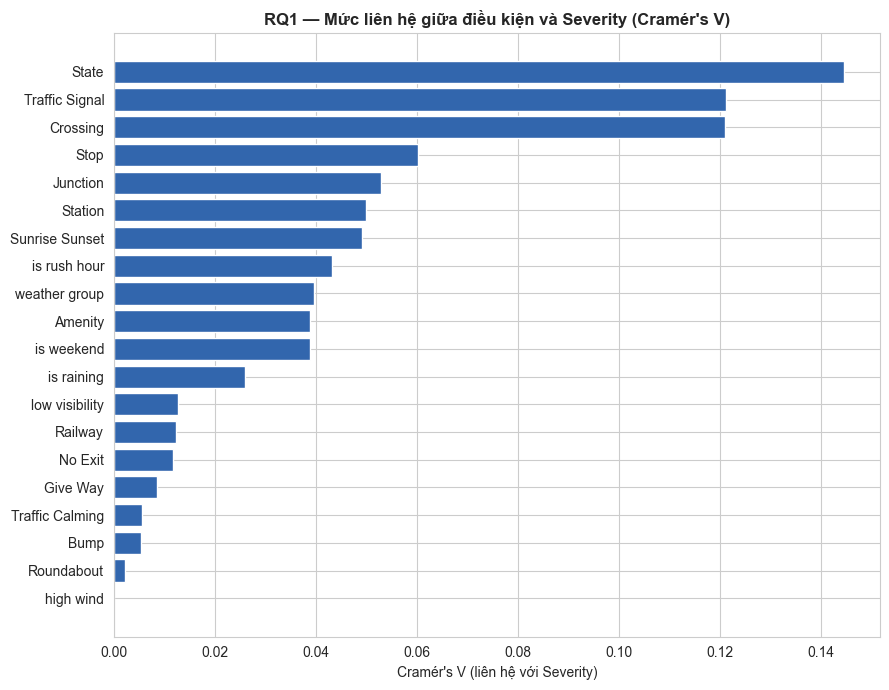

Top 8 Cramér's V:
State             0.1444
Traffic_Signal    0.1211
Crossing          0.1210
Stop              0.0601
Junction          0.0529
Station           0.0500
Sunrise_Sunset    0.0492
is_rush_hour      0.0431
dtype: float64


In [5]:
from scipy.stats import chi2_contingency

def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    r, k = ct.shape
    phi2 = chi2 / n
    # bias correction (Bergsma 2013)
    phi2c = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rc = r - (r-1)**2/(n-1)
    kc = k - (k-1)**2/(n-1)
    return np.sqrt(phi2c / max(1e-12, min(kc-1, rc-1)))

cat_for_rq1 = (['weather_group', 'Sunrise_Sunset', 'State', 'low_visibility',
                'is_rush_hour', 'is_weekend', 'is_raining', 'high_wind'] + INFRA)

cv = {c: cramers_v(df[c], y) for c in cat_for_rq1}
cv_s = pd.Series(cv).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(len(cv_s)), cv_s.values[::-1], color='#3266ad')
ax.set_yticks(range(len(cv_s)))
ax.set_yticklabels([c.replace('_', ' ') for c in cv_s.index[::-1]])
ax.set_xlabel("Cramér's V (liên hệ với Severity)")
ax.set_title("RQ1 — Mức liên hệ giữa điều kiện và Severity (Cramér's V)")
plt.tight_layout(); plt.savefig('clf_cramers_v.png', dpi=150, bbox_inches='tight'); plt.show()

print("Top 8 Cramér's V:")
print(cv_s.head(8).round(4))

In [6]:
# Odds Ratio: xác suất tai nạn NGHIÊM TRỌNG (Severity 3-4) theo từng điều kiện — RQ1
y_bin = (y >= 3).astype('int8')     # gộp nhị phân đúng như RQ1 trong Project Planning

def odds_ratio(flag):
    a = ((flag == 1) & (y_bin == 1)).sum(); b = ((flag == 1) & (y_bin == 0)).sum()
    c = ((flag == 0) & (y_bin == 1)).sum(); d = ((flag == 0) & (y_bin == 0)).sum()
    return ((a + .5) * (d + .5)) / ((b + .5) * (c + .5))

or_cols = ['low_visibility', 'is_night', 'is_raining', 'high_wind', 'is_rush_hour',
           'is_weekend', 'Junction', 'Crossing', 'Traffic_Signal', 'Stop', 'Railway']
or_s = pd.Series({c: odds_ratio(df[c]) for c in or_cols}).sort_values(ascending=False)

print('Odds Ratio cho Severity cao (3-4), OR > 1 = làm tăng rủi ro:')
print(or_s.round(3).to_string())
print(f'\nTỉ lệ tai nạn nghiêm trọng (3-4) toàn tập: {y_bin.mean()*100:.2f}%')

Odds Ratio cho Severity cao (3-4), OR > 1 = làm tăng rủi ro:
high_wind         4.138
Junction          1.573
is_raining        1.249
is_weekend        1.171
is_rush_hour      1.030
low_visibility    0.980
is_night          0.951
Railway           0.736
Traffic_Signal    0.391
Crossing          0.284
Stop              0.268

Tỉ lệ tai nạn nghiêm trọng (3-4) toàn tập: 19.46%


## 4. Encoding, Stratified Split & Class Imbalance



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# --- Bản encoded dùng cho cả 3 model (XGBoost / LightGBM / HistGradientBoosting) ---
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float32)
X_train_enc = X_train.copy(); X_test_enc = X_test.copy()
X_train_enc[CAT_FEATURES] = enc.fit_transform(X_train[CAT_FEATURES])
X_test_enc[CAT_FEATURES]  = enc.transform(X_test[CAT_FEATURES])
X_train_enc = X_train_enc.astype(np.float32); X_test_enc = X_test_enc.astype(np.float32)

# --- Nhãn 0-based cho XGBoost / LightGBM / HistGradientBoosting ---
classes_sorted = np.sort(y.unique())
cls2idx = {c: i for i, c in enumerate(classes_sorted)}
idx2cls = {i: c for c, i in cls2idx.items()}
y_train_idx = y_train.map(cls2idx).values
y_test_idx  = y_test.map(cls2idx).values
N_CLASSES = len(classes_sorted)


CLASS_WEIGHT_POWER = 0.5          

def tempered_class_weight(y_idx, power=CLASS_WEIGHT_POWER):
    counts = np.bincount(y_idx, minlength=N_CLASSES).astype(float)
    w = (counts.sum() / (N_CLASSES * np.maximum(counts, 1))) ** power
    w = w / w[y_idx].mean()       # chuan hoa: trong so trung binh tren moi mau = 1
    return w

CW_ARR  = tempered_class_weight(y_train_idx)            # mang theo chi so lop 0..K-1
CLASS_W = {i: float(CW_ARR[i]) for i in range(N_CLASSES)}   # dict cho LightGBM
sw_train = CW_ARR[y_train_idx]

dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
print('Phan bo lop (train) & trong so:')
for i, c in enumerate(classes_sorted):
    full = (1 / dist[c]) / N_CLASSES
    print(f'  Severity {c}: {dist[c]*100:6.2f}%  | balanced = {full:7.2f} | tempered(p={CLASS_WEIGHT_POWER}) = {CW_ARR[i]:.2f}')

# [FIX] Tach validation tu TRAIN o day (thay vi trong cell XGBoost) de ca 3 model
# dung CUNG mot tap train-fit / validation -> so sanh cong bang va khong phu thuoc thu tu chay cell.
X_tr, X_val, y_tr_idx, y_val_idx, sw_tr, sw_val = train_test_split(
    X_train_enc, y_train_idx, sw_train,
    test_size=0.15, random_state=RANDOM_STATE, stratify=y_train_idx)
print(f'Train-fit: {len(X_tr):,} | Validation (early stopping): {len(X_val):,}')

Train: 6,182,715 | Test: 1,545,679
Phan bo lop (train) & trong so:
  Severity 1:   0.87%  | balanced =   28.68 | tempered(p=0.5) = 6.87
  Severity 2:  79.67%  | balanced =    0.31 | tempered(p=0.5) = 0.72
  Severity 3:  16.81%  | balanced =    1.49 | tempered(p=0.5) = 1.56
  Severity 4:   2.65%  | balanced =    9.44 | tempered(p=0.5) = 3.94
Train-fit: 5,255,307 | Validation (early stopping): 927,408


In [8]:
# Hàm đánh giá dùng chung cho cả 3 model
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, classification_report)
import numpy as np

RESULTS = {}

def evaluate(name, y_true, y_pred, y_proba=None, verbose=True):
    # Chỉ giữ các chỉ số quan trọng
    res = {
        'Accuracy':        accuracy_score(y_true, y_pred),
        'Balanced Acc':    balanced_accuracy_score(y_true, y_pred),
        'F1 (macro)':      f1_score(y_true, y_pred, average='macro'),
        'F1 (weighted)':   f1_score(y_true, y_pred, average='weighted'),
        'AUC (OvR)':       np.nan
    }
    
    if y_proba is not None:
        try:
            res['AUC (OvR)'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except Exception as e:
            print('  (AUC lỗi:', e, ')')
    
    RESULTS[name] = res
    
    if verbose:
        print(f'{name} performance:')
        for k, v in res.items():
            if v is None or (isinstance(v, float) and np.isnan(v)):
                continue
            print(f'  {k:<14} = {v:.4f}')
        print()
        print(classification_report(y_true, y_pred, digits=3))
    
    return res

## 5. Model 1 — **XGBoost**

Dùng API sklearn hiện hành của XGBoost:
- `device='cuda'` / `'cpu'` thay cho `gpu_hist` (đã deprecated), `tree_method='hist'` là mặc định và nhanh hơn.
- `early_stopping_rounds` khai báo **trong constructor** của sklearn API.
- `multi_strategy='one_output_per_tree'` (hoặc `'multi_output_tree'`) cho bài toán multi-class.
- Hỗ trợ `QuantileDMatrix` tiết kiệm bộ nhớ và **categorical native** (`enable_categorical=True`).

In [9]:
from xgboost import XGBClassifier

# Current XGBoost sklearn API: device + hist; early_stopping_rounds is set on estimator.
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=N_CLASSES,
    n_estimators=500,
    learning_rate=0.20,
    max_depth=6,
    max_bin=128,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.5,
    reg_alpha=0.1,
    tree_method='hist',
    device='cpu',
    eval_metric='mlogloss',
    early_stopping_rounds=25,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb.fit(
    X_tr, y_tr_idx,
    sample_weight=sw_tr,
    eval_set=[(X_val, y_val_idx)],
    sample_weight_eval_set=[sw_val],   
    verbose=False
)

print(f'Best iteration: {xgb.best_iteration} / 500 (early stopping)')

proba_xgb = xgb.predict_proba(X_test_enc)
proba_xgb_val = xgb.predict_proba(X_val)      

pred_xgb = classes_sorted[proba_xgb.argmax(axis=1)]
_ = evaluate('XGBoost', y_test, pred_xgb, proba_xgb)


Best iteration: 499 / 500 (early stopping)
XGBoost performance:
  Accuracy       = 0.8085
  Balanced Acc   = 0.6527
  F1 (macro)     = 0.5535
  F1 (weighted)  = 0.8168
  AUC (OvR)      = 0.8982

              precision    recall  f1-score   support

           1      0.300     0.795     0.435     13473
           2      0.913     0.858     0.884   1231396
           3      0.548     0.657     0.598    259868
           4      0.293     0.301     0.297     40942

    accuracy                          0.808   1545679
   macro avg      0.513     0.653     0.554   1545679
weighted avg      0.830     0.808     0.817   1545679



**Nhận xét:** XGBoost cho baseline boosting mạnh ngay với cấu hình mặc định hợp lý; `tree_method='hist'` giúp train nhanh trên dữ liệu lớn, và early stopping dừng trước khi validation loss đi ngang → không overfit.

## 6. Model 2 — **LightGBM**

LightGBM dùng **leaf-wise growth** + GOSS + EFB → thường nhanh nhất trên dữ liệu lớn nhiều chiều. Ưu điểm dùng ngay ở đây: **hỗ trợ categorical feature native** (không cần one-hot `State`, `weather_group`).

In [10]:
import lightgbm as lgb

# Xác định cột phân loại
cat_idx = [X_train_enc.columns.get_loc(c) for c in CAT_FEATURES]


lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=N_CLASSES,
    
    # === TỐI ƯU TỐC ĐỘ ===
    n_estimators=1500,          
    learning_rate=0.15,        
    num_leaves=63,              
    max_depth=-1,               
    min_child_samples=40,
    
    # === Giữ nguyên chất lượng ===
    feature_fraction=0.85,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_lambda=1.0,
    class_weight=CLASS_W,       
    random_state=RANDOM_STATE,
    n_jobs=-1,                  
    verbose=-1
)

lgbm.fit(
    X_tr, y_tr_idx,
    eval_set=[(X_val, y_val_idx)],
    eval_metric='multi_logloss',
    eval_class_weight=[CLASS_W],     
    categorical_feature=cat_idx,
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),  
        lgb.log_evaluation(0)
    ]
)

print(f'Best iteration: {lgbm.best_iteration_} / 1500')

proba_lgb = lgbm.predict_proba(X_test_enc)
proba_lgb_val = lgbm.predict_proba(X_val)     
# [FIX] Dung classes_sorted thay cho .map(idx2cls) — tranh loi neu idx2cls bi ghi de
pred_lgb = classes_sorted[proba_lgb.argmax(axis=1)]

_ = evaluate('LightGBM', y_test, pred_lgb, proba_lgb)

Best iteration: 1500 / 1500
LightGBM performance:
  Accuracy       = 0.8310
  Balanced Acc   = 0.6797
  F1 (macro)     = 0.5993
  F1 (weighted)  = 0.8375
  AUC (OvR)      = 0.9174

              precision    recall  f1-score   support

           1      0.380     0.779     0.511     13473
           2      0.924     0.874     0.898   1231396
           3      0.595     0.706     0.646    259868
           4      0.327     0.360     0.342     40942

    accuracy                          0.831   1545679
   macro avg      0.556     0.680     0.599   1545679
weighted avg      0.848     0.831     0.837   1545679



**Nhận xét:** LightGBM hỗ trợ categorical feature native và có độ chính xác để đối chiếu trực tiếp với XGBoost. Đánh đổi: leaf-wise dễ overfit hơn nếu `num_leaves` quá lớn — ta khống chế bằng `min_child_samples=40` và early stopping.

## 7. Model 3 — **HistGradientBoosting** (scikit-learn)

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier


hgb = HistGradientBoostingClassifier(
    loss='log_loss',
    max_iter=500,
    learning_rate=0.20,
    max_depth=6,
    max_bins=128,
    early_stopping=True,
    validation_fraction=0.15,   
    n_iter_no_change=25,
    min_samples_leaf=20,
    l2_regularization=1.5,
    random_state=RANDOM_STATE,
    verbose=0
)

hgb.fit(X_tr, y_tr_idx, sample_weight=sw_tr)

print(f'So iteration thuc te: {hgb.n_iter_} / 500  (early stopping)')

proba_hgb = hgb.predict_proba(X_test_enc)
proba_hgb_val = hgb.predict_proba(X_val)      
pred_hgb = classes_sorted[proba_hgb.argmax(axis=1)]   

_ = evaluate('HistGradientBoosting', y_test, pred_hgb, proba_hgb)

So iteration thuc te: 500 / 500  (early stopping)
HistGradientBoosting performance:
  Accuracy       = 0.8105
  Balanced Acc   = 0.6554
  F1 (macro)     = 0.5568
  F1 (weighted)  = 0.8188
  AUC (OvR)      = 0.9001

              precision    recall  f1-score   support

           1      0.305     0.792     0.441     13473
           2      0.915     0.858     0.886   1231396
           3      0.554     0.664     0.604    259868
           4      0.287     0.307     0.297     40942

    accuracy                          0.810   1545679
   macro avg      0.515     0.655     0.557   1545679
weighted avg      0.832     0.810     0.819   1545679



**Nhận xét:** HistGradientBoosting thường cho kết quả rất sát LightGBM (cùng cơ chế histogram) với tốc độ tương đương, và là lựa chọn gọn nhất vì không cần thư viện ngoài. Đánh đổi so với LightGBM: không hỗ trợ categorical native ở cấu hình này, và không có `class_weight` nên phải truyền `sample_weight` thủ công (dùng cùng tempered weight như 2 model kia).

## 8. So sánh 3 Model & Đánh giá (RQ2)

In [12]:
# Bảng so sánh 3 mô hình
comparison = pd.DataFrame(RESULTS).T


comparison = comparison[[
    'Accuracy',
    'Balanced Acc',
    'F1 (macro)',
    'F1 (weighted)',
    'AUC (OvR)'
]].astype(float).round(4)

# Sắp xếp theo F1 macro giảm dần — ưu tiên phát hiện tai nạn nặng
comparison = comparison.sort_values('F1 (macro)', ascending=False)

# In ra màn hình
print(comparison.to_string())

# Chọn mô hình tốt nhất
BEST_MODEL = comparison.index[0]
print(f'\n Mô hình tốt nhất theo F1 (macro): {BEST_MODEL}')

# Lưu ra file để nộp/báo cáo
comparison.to_csv('clf_model_comparison.csv')
print('\nĐã lưu kết quả vào: clf_model_comparison.csv')

                      Accuracy  Balanced Acc  F1 (macro)  F1 (weighted)  AUC (OvR)
LightGBM                0.8310        0.6797      0.5993         0.8375     0.9174
HistGradientBoosting    0.8105        0.6554      0.5568         0.8188     0.9001
XGBoost                 0.8085        0.6527      0.5535         0.8168     0.8982

 Mô hình tốt nhất theo F1 (macro): LightGBM

Đã lưu kết quả vào: clf_model_comparison.csv


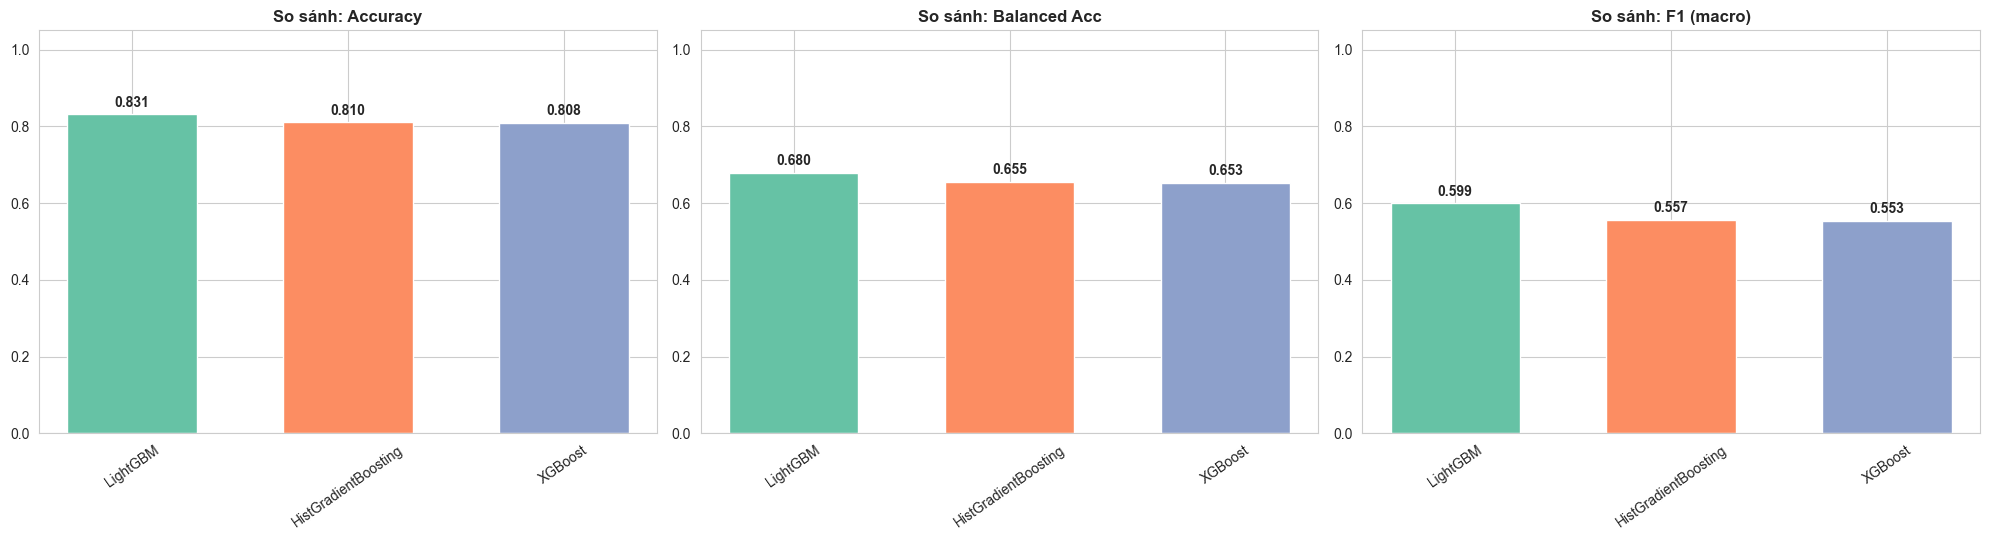

In [13]:
order = list(comparison.index)  
cmp_o = comparison.loc[order]


colors_m = sns.color_palette('Set2', len(order))

# --- Biểu đồ so sánh ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

for ax, metric, fmt in zip(axes,
                           ['Accuracy', 'Balanced Acc', 'F1 (macro)'],
                           ['{:.3f}', '{:.3f}', '{:.3f}']):
    vals = cmp_o[metric].values
    bars = ax.bar(order, vals, color=colors_m, width=0.6)
    ax.set_title(f'So sánh: {metric}')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=35)
    
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width()/2, v + 0.02,
                    fmt.format(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Confusion Matrix & ROC one-vs-rest (model tốt nhất)

RQ3 recovery cache saved: rq3_context.npz


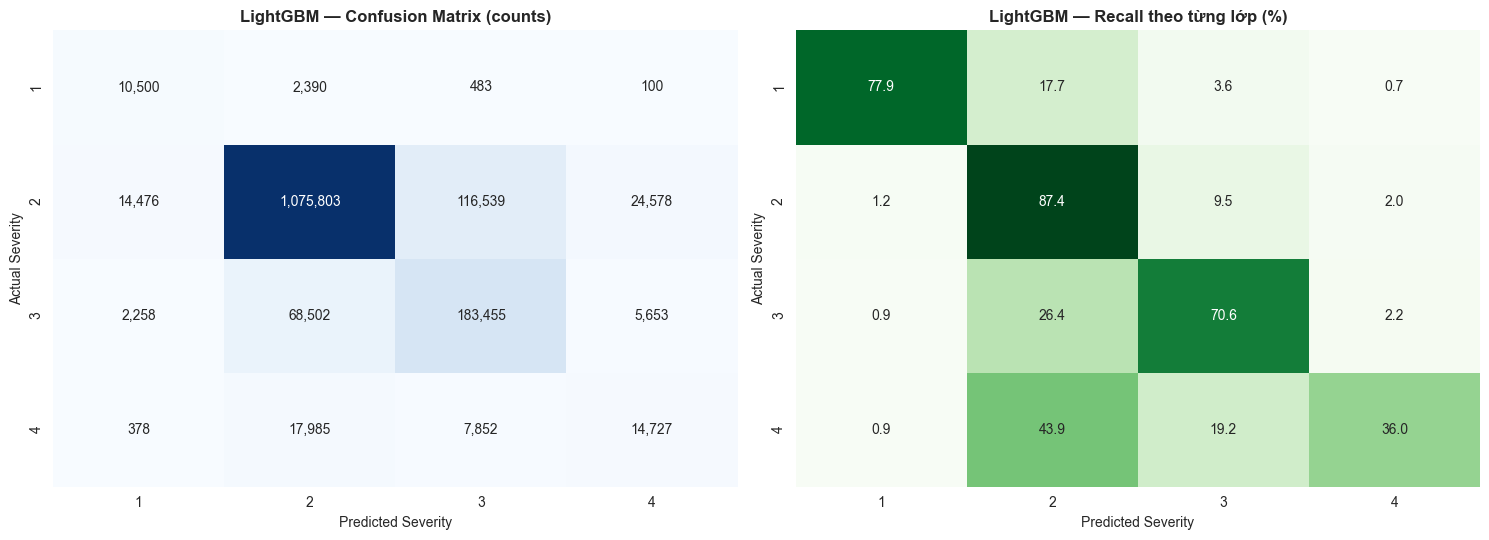

In [14]:
from sklearn.metrics import confusion_matrix 
PREDS  = {'XGBoost': pred_xgb,  'LightGBM': pred_lgb,  'HistGradientBoosting': pred_hgb}
PROBAS = {'XGBoost': proba_xgb, 'LightGBM': proba_lgb, 'HistGradientBoosting': proba_hgb}

best_pred, best_proba = PREDS[BEST_MODEL], PROBAS[BEST_MODEL]

# Cache compact RQ3 inputs so the hotspot analysis can recover after a kernel restart.
# The cache contains only coordinates, true labels, model probabilities, and model metadata.
RQ3_CACHE = 'rq3_context.npz'
np.savez_compressed(
    RQ3_CACHE,
    train_lat=X_train['Start_Lat'].to_numpy(dtype=np.float32),
    train_lng=X_train['Start_Lng'].to_numpy(dtype=np.float32),
    train_y=y_train.to_numpy(dtype=np.int8),
    test_lat=X_test['Start_Lat'].to_numpy(dtype=np.float32),
    test_lng=X_test['Start_Lng'].to_numpy(dtype=np.float32),
    test_y=y_test.to_numpy(dtype=np.int8),
    best_proba=np.asarray(best_proba, dtype=np.float32),
    best_model=np.asarray(BEST_MODEL),
    classes_sorted=np.asarray(classes_sorted, dtype=np.int8),
)
print(f'RQ3 recovery cache saved: {RQ3_CACHE}')

# === Tính ma trận nhầm lẫn ===
cm = confusion_matrix(y_test, best_pred, labels=classes_sorted)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

# === Vẽ biểu đồ ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=classes_sorted, yticklabels=classes_sorted, ax=axes[0])
axes[0].set_title(f'{BEST_MODEL} — Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted Severity')
axes[0].set_ylabel('Actual Severity')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens', cbar=False,
            xticklabels=classes_sorted, yticklabels=classes_sorted, ax=axes[1])
axes[1].set_title(f'{BEST_MODEL} — Recall theo từng lớp (%)')
axes[1].set_xlabel('Predicted Severity')
axes[1].set_ylabel('Actual Severity')

plt.tight_layout()
plt.savefig('clf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

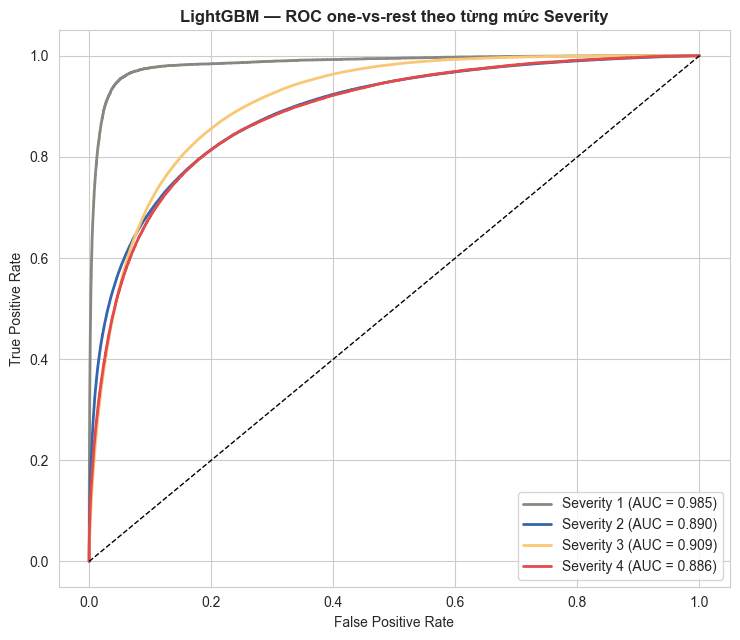

In [15]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=classes_sorted)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
palette = ['#888780', '#3266ad', '#FAC775', '#E24B4A']
for i, cls in enumerate(classes_sorted):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_proba[:, i])
    ax.plot(fpr, tpr, lw=2, color=palette[i % 4],
            label=f'Severity {cls} (AUC = {auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title(f'{BEST_MODEL} — ROC one-vs-rest theo từng mức Severity')
ax.legend(loc='lower right'); plt.tight_layout()
plt.savefig('clf_roc_ovr.png', dpi=150, bbox_inches='tight'); plt.show()

## 10. Feature Importance — Yếu tố nào drive Severity? (RQ1)

Ưu tiên **SHAP** (`TreeExplainer`) vì nó cho biết cả độ mạnh **và hướng** tác động, lại ít bị lệch bởi đa cộng tuyến đã phát hiện ở phần 3.

> Chạy trên mẫu 20k dòng test cho nhanh; tăng `SHAP_N` nếu cần độ mịn.

RQ3 recovery cache saved: rq3_context.npz


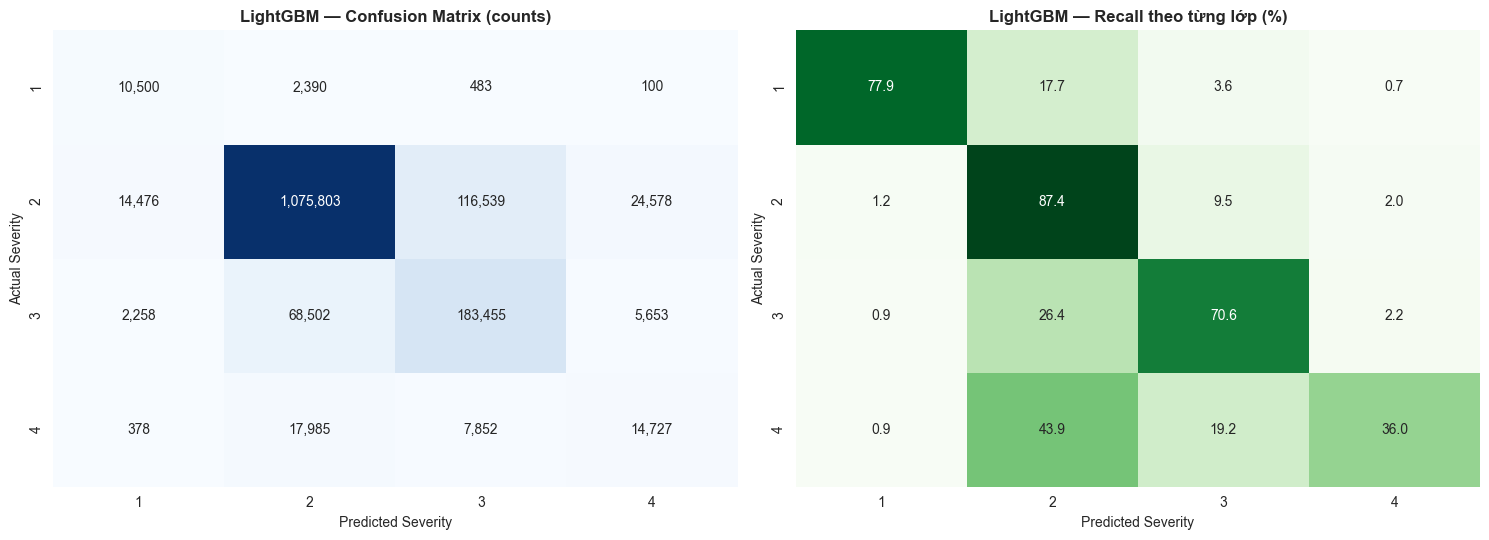

In [17]:
from sklearn.metrics import confusion_matrix 
PREDS  = {'XGBoost': pred_xgb,  'LightGBM': pred_lgb,  'HistGradientBoosting': pred_hgb}
PROBAS = {'XGBoost': proba_xgb, 'LightGBM': proba_lgb, 'HistGradientBoosting': proba_hgb}

best_pred, best_proba = PREDS[BEST_MODEL], PROBAS[BEST_MODEL]

# Cache compact RQ3 inputs so the hotspot analysis can recover after a kernel restart.
# The cache contains only coordinates, true labels, model probabilities, and model metadata.
RQ3_CACHE = 'rq3_context.npz'
np.savez_compressed(
    RQ3_CACHE,
    train_lat=X_train['Start_Lat'].to_numpy(dtype=np.float32),
    train_lng=X_train['Start_Lng'].to_numpy(dtype=np.float32),
    train_y=y_train.to_numpy(dtype=np.int8),
    test_lat=X_test['Start_Lat'].to_numpy(dtype=np.float32),
    test_lng=X_test['Start_Lng'].to_numpy(dtype=np.float32),
    test_y=y_test.to_numpy(dtype=np.int8),
    best_proba=np.asarray(best_proba, dtype=np.float32),
    best_model=np.asarray(BEST_MODEL),
    classes_sorted=np.asarray(classes_sorted, dtype=np.int8),
)
print(f'RQ3 recovery cache saved: {RQ3_CACHE}')

# === Tính ma trận nhầm lẫn ===
cm = confusion_matrix(y_test, best_pred, labels=classes_sorted)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

# === Vẽ biểu đồ ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=classes_sorted, yticklabels=classes_sorted, ax=axes[0])
axes[0].set_title(f'{BEST_MODEL} — Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted Severity')
axes[0].set_ylabel('Actual Severity')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens', cbar=False,
            xticklabels=classes_sorted, yticklabels=classes_sorted, ax=axes[1])
axes[1].set_title(f'{BEST_MODEL} — Recall theo từng lớp (%)')
axes[1].set_xlabel('Predicted Severity')
axes[1].set_ylabel('Actual Severity')

plt.tight_layout()
plt.savefig('clf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét RQ1 (số thật từ SHAP của LightGBM, mẫu 20k dòng test):**

Importance gộp theo nhóm biến: **Thời gian 47.9% · Vị trí 31.8% · Thời tiết 11.1% · Hạ tầng đường 9.2%**.

1. **`year` là feature mạnh nhất (0.6342)** — đây là **cảnh báo data drift**, không phải phát hiện khoa học. Cách MapQuest/Bing gán nhãn `Severity` thay đổi qua các năm, nên model đang học "vụ này thuộc năm nào" thay vì "điều kiện gì gây nặng". Bắt buộc phải ghi vào Limitations; muốn sạch thì bỏ `year` rồi train lại và so kết quả.
2. **Vị trí đứng thứ hai** (`State` 0.5094, `Start_Lat` 0.2622, `Start_Lng` 0.2017) → severity phụ thuộc mạnh vào bối cảnh địa lý / loại đường (highway vs nội thị). Đây chính là cầu nối sang RQ3 (hotspot).
3. **Thời tiết chỉ 11.1%** — thấp hơn nhiều so với trực giác. Rất đáng viết vào Discussion, vì hầu hết người đọc mặc định thời tiết là yếu tố số 1.
4. **Hạ tầng đường thấp nhất (9.2%) nhưng có hướng rõ ràng**: Odds Ratio ở phần 3 cho `Traffic_Signal` 0.391, `Crossing` 0.284, `Stop` 0.268 — tức chỗ có đèn/vạch/biển dừng làm **giảm** mức nghiêm trọng (xe buộc chạy chậm), còn `Junction` 1.573 và `high_wind` 4.138 làm **tăng**. Kết quả phản trực giác này là điểm mạnh của báo cáo.
5. **Correlation ≠ causation:** `high_wind` OR = 4.14 không có nghĩa gió to *gây ra* tai nạn nặng — gió mạnh thường đi cùng đường cao tốc trống trải, tốc độ cao. Biến gây nhiễu thật là **tốc độ giới hạn**, mà dataset này **không có**.

## 12. RQ3 — Bản đồ hotspot dự đoán vs thống kê lịch sử

### Câu hỏi
> *Bản đồ điểm nóng tai nạn (hotspot) dự đoán bằng mô hình có trùng khớp với vị trí tai nạn thực tế bao nhiêu %, so với thống kê lịch sử đơn thuần?*




In [18]:
import matplotlib.colors as mcolors     # dung cho thang mau log o ban do

# Neu kernel vua restart, nap lai cache tao o PHAN 9 - Confusion Matrix (sau khi chon model).
_need = ['X_train', 'y_train', 'X_test', 'y_test', 'best_proba', 'BEST_MODEL', 'classes_sorted']
_missing = [v for v in _need if v not in globals()]
if _missing:
    if not os.path.exists('rq3_context.npz'):
        raise RuntimeError(
            "RQ3 chua co du lieu trong RAM va khong tim thay rq3_context.npz. "
            "Chay notebook tu dau den het phan 9 (Confusion Matrix) de tao cache, "
            "sau do co the chay lai RQ3 sau khi restart kernel."
        )
    _rq3 = np.load('rq3_context.npz', allow_pickle=False)
    X_train = pd.DataFrame({'Start_Lat': _rq3['train_lat'], 'Start_Lng': _rq3['train_lng']})
    y_train = pd.Series(_rq3['train_y'])
    X_test = pd.DataFrame({'Start_Lat': _rq3['test_lat'], 'Start_Lng': _rq3['test_lng']})
    y_test = pd.Series(_rq3['test_y'])
    best_proba = _rq3['best_proba']
    BEST_MODEL = str(_rq3['best_model'].item())
    classes_sorted = _rq3['classes_sorted']
    print('Da nap lai du lieu RQ3 tu rq3_context.npz')
else:
    print('Da co du bien RQ2 trong RAM ->', BEST_MODEL)

# ============================================
# RQ3 - Buoc 1: xay dung luoi (grid) va tong hop 3 ban do
# ============================================
GRID_DEG = 0.1            # kich thuoc o luoi (do); 0.1 do ~ 11 km
TOP_K    = 200            # so o duoc coi la "hotspot"
LAT_MIN, LAT_MAX = 24.0, 50.0        # gioi han CONUS (48 bang lien ke)
LNG_MIN, LNG_MAX = -125.0, -66.0
_OFF = 4000               # offset de khoa o luoi khong bi trung khi bin am

# Cot xac suat cua cac lop nghiem trong (Severity 3 va 4) trong best_proba
sev_pos = [i for i, c in enumerate(classes_sorted) if c >= 3]
print(f'Cot xac suat nghiem trong: Severity {[int(classes_sorted[i]) for i in sev_pos]}')

def _conus(d):
    m = d['lat'].between(LAT_MIN, LAT_MAX) & d['lng'].between(LNG_MIN, LNG_MAX)
    return d.loc[m].copy()

# --- TAP TEST: su that (actual) + du doan cua model (out-of-sample) ---
test_base = _conus(pd.DataFrame({
    'lat':           X_test['Start_Lat'].to_numpy(dtype=np.float32),
    'lng':           X_test['Start_Lng'].to_numpy(dtype=np.float32),
    'actual_severe': (y_test.to_numpy() >= 3).astype(np.int8),
    'prob_severe':   best_proba[:, sev_pos].sum(axis=1).astype(np.float32),
}))

# --- TAP TRAIN: thong ke lich su don thuan (baseline, KHONG dung model) ---
train_base = _conus(pd.DataFrame({
    'lat':         X_train['Start_Lat'].to_numpy(dtype=np.float32),
    'lng':         X_train['Start_Lng'].to_numpy(dtype=np.float32),
    'hist_severe': (y_train.to_numpy() >= 3).astype(np.int8),
}))
print(f'Diem trong CONUS: test {len(test_base):,} | train {len(train_base):,}')

def _mkkey(lat_bin, lng_bin):
    """Ghep (lat_bin, lng_bin) thanh mot khoa int64 duy nhat cho moi o luoi."""
    return (lat_bin.astype(np.int64) + _OFF) * 100_000 + (lng_bin.astype(np.int64) + _OFF)

def build_grid(deg=GRID_DEG):
    """Gan tai nan vao o luoi roi tong hop: THUC TE / MODEL / LICH SU."""
    t = test_base.assign(
        lat_bin=np.floor(test_base['lat'] / deg).astype(np.int32),
        lng_bin=np.floor(test_base['lng'] / deg).astype(np.int32))
    h = train_base.assign(
        lat_bin=np.floor(train_base['lat'] / deg).astype(np.int32),
        lng_bin=np.floor(train_base['lng'] / deg).astype(np.int32))

    g_t = (t.groupby(['lat_bin', 'lng_bin'], sort=False)
             .agg(n_test=('actual_severe', 'size'),
                  actual_severe=('actual_severe', 'sum'),
                  exp_severe=('prob_severe', 'sum'),
                  mean_prob=('prob_severe', 'mean'))
             .reset_index())
    g_h = (h.groupby(['lat_bin', 'lng_bin'], sort=False)
             .agg(n_train=('hist_severe', 'size'),
                  hist_severe=('hist_severe', 'sum'))
             .reset_index())

    g = g_t.merge(g_h, on=['lat_bin', 'lng_bin'], how='outer').fillna(0)
    g['key']   = _mkkey(g['lat_bin'].to_numpy(), g['lng_bin'].to_numpy())
    g['lat_c'] = (g['lat_bin'] + 0.5) * deg
    g['lng_c'] = (g['lng_bin'] + 0.5) * deg
    g['hist_rate'] = np.where(g['n_train'] > 0, g['hist_severe'] / g['n_train'], 0.0)
    return g

grid = build_grid(GRID_DEG)

print(f'\nSo o luoi co du lieu     : {len(grid):,}  (o {GRID_DEG} do ~ {GRID_DEG*111:.0f} km)')
print(f'Tai nan test trong luoi  : {int(grid["n_test"].sum()):,}')
print(f'Tai nan nghiem trong THAT: {int(grid["actual_severe"].sum()):,}')
print(f'Ky vong tu model         : {grid["exp_severe"].sum():,.0f}')
grid.sort_values("actual_severe", ascending=False).head()

Da co du bien RQ2 trong RAM -> LightGBM
Cot xac suat nghiem trong: Severity [3, 4]
Diem trong CONUS: test 1,545,679 | train 6,182,715

So o luoi co du lieu     : 33,669  (o 0.1 do ~ 11 km)
Tai nan test trong luoi  : 1,545,679
Tai nan nghiem trong THAT: 300,810
Ky vong tu model         : 462,345


,lat_bin,lng_bin,n_test,actual_severe,exp_severe,mean_prob,n_train,hist_severe,key,lat_c,lng_c,hist_rate
6818,340,-1183,10077.0,2360.0,3383.056885,0.335721,40178.0,9306.0,434002817,34.05,-118.25,0.231619
6393,337,-844,4258.0,2285.0,2832.605957,0.665243,16917.0,9019.0,433703156,33.75,-84.35,0.533132
21320,408,-740,5466.0,1760.0,2487.295898,0.455049,22165.0,7168.0,440803260,40.85,-73.95,0.323393
6625,339,-1182,4794.0,1601.0,2071.038818,0.432006,19103.0,6385.0,433902818,33.95,-118.15,0.334241
53,258,-803,7500.0,1420.0,1847.124512,0.246283,29966.0,5721.0,425803197,25.85,-80.25,0.190916


In [19]:
# ============================================
# RQ3 - Buoc 2: dinh nghia hotspot va do % chong lap (IoU / Overlap)
# ============================================
def topk_cells(g, col, k):
    """Khoa cua K o co gia tri cao nhat theo cot col."""
    return g.nlargest(k, col)['key'].to_numpy()

def iou(a, b):
    u = len(np.union1d(a, b))
    return len(np.intersect1d(a, b)) / u if u else np.nan

def overlap_pct(a, ref):
    return len(np.intersect1d(a, ref)) / len(ref) * 100 if len(ref) else np.nan

def captured_pct(g, cells, col='actual_severe'):
    """% tai nan nghiem trong THUC TE nam trong tap o cells."""
    tot = g[col].sum()
    if tot == 0:
        return np.nan
    m = np.isin(g['key'].to_numpy(), cells)
    return g.loc[m, col].sum() / tot * 100

# Ba ban do hotspot, cung TOP_K o
H_actual = topk_cells(grid, 'actual_severe', TOP_K)   # SU THAT tren tap test
H_model  = topk_cells(grid, 'exp_severe',    TOP_K)   # MODEL du doan (tong xac suat)
H_hist   = topk_cells(grid, 'hist_severe',   TOP_K)   # THONG KE LICH SU (baseline)

rq3 = pd.DataFrame([
    {'Phuong phap': f'Model ({BEST_MODEL})',
     'IoU vs thuc te':          iou(H_model, H_actual),
     'Overlap % vs thuc te':    overlap_pct(H_model, H_actual),
     '% tai nan nang bat duoc': captured_pct(grid, H_model)},
    {'Phuong phap': 'Thong ke lich su (baseline)',
     'IoU vs thuc te':          iou(H_hist, H_actual),
     'Overlap % vs thuc te':    overlap_pct(H_hist, H_actual),
     '% tai nan nang bat duoc': captured_pct(grid, H_hist)},
]).round(4)

print(f'Hotspot = TOP {TOP_K} o luoi, kich thuoc o {GRID_DEG} do (~{GRID_DEG*111:.0f} km)')
print(f'Tong so o co du lieu: {len(grid):,}\n')
print(rq3.to_string(index=False))

d_iou = rq3.loc[0, 'IoU vs thuc te']          - rq3.loc[1, 'IoU vs thuc te']
d_ovl = rq3.loc[0, 'Overlap % vs thuc te']    - rq3.loc[1, 'Overlap % vs thuc te']
d_cap = rq3.loc[0, '% tai nan nang bat duoc'] - rq3.loc[1, '% tai nan nang bat duoc']
print('\n=> MODEL so voi THONG KE LICH SU don thuan (cau tra loi truc tiep cho RQ3):')
print(f'   IoU        : {d_iou:+.4f}')
print(f'   Overlap %  : {d_ovl:+.2f} diem %')
print(f'   Bat duoc % : {d_cap:+.2f} diem %')
print('   (duong = model tot hon lich su; am/xap xi 0 = lich su da du tot)')

print(f'\nO trung nhau ca 3 ban do : {len(np.intersect1d(np.intersect1d(H_model, H_hist), H_actual))}')
print(f'O chi model chon         : {len(np.setdiff1d(H_model, H_hist))}')
print(f'O chi lich su chon       : {len(np.setdiff1d(H_hist, H_model))}')

Hotspot = TOP 200 o luoi, kich thuoc o 0.1 do (~11 km)
Tong so o co du lieu: 33,669

                Phuong phap  IoU vs thuc te  Overlap % vs thuc te  % tai nan nang bat duoc
           Model (LightGBM)          0.8265                  90.5                  39.3870
Thong ke lich su (baseline)          0.9231                  96.0                  39.8108

=> MODEL so voi THONG KE LICH SU don thuan (cau tra loi truc tiep cho RQ3):
   IoU        : -0.0966
   Overlap %  : -5.50 diem %
   Bat duoc % : -0.42 diem %
   (duong = model tot hon lich su; am/xap xi 0 = lich su da du tot)

O trung nhau ca 3 ban do : 177
O chi model chon         : 19
O chi lich su chon       : 19


### Kết luận RQ3 — điền số thật từ output ở trên

Trả lời trực tiếp câu hỏi RQ3 theo mẫu:

> Với lưới **0.1°** (~11 km) và **TOP 200 ô**, bản đồ hotspot do model **LightGBM** dự đoán trùng khớp **____%** với hotspot thực tế (IoU = ____), so với **____%** (IoU = ____) của thống kê lịch sử đơn thuần — chênh lệch **____ điểm %**. Vùng hotspot của model bắt được **____%** tổng số tai nạn nghiêm trọng trong tập test.


## 13. Tổng kết — Bước 5 hoàn thành (RQ1 · RQ2 · RQ3)

### RQ2 — So sánh 3 model

| Model | Cơ chế | Ghi chú kỹ thuật |
|---|---|---|
| **XGBoost** | gradient boosting | API hiện hành: `device=`, `tree_method='hist'`, early stopping trong constructor |
| **LightGBM** | leaf-wise + GOSS/EFB | categorical native |
| **HistGradientBoosting** | histogram-based (sklearn) | early stopping nội bộ, xử lý NaN native, không cần thư viện ngoài |

### RQ1 — Yếu tố drive Severity
Thứ tự nhóm biến theo SHAP: **Thời gian > Vị trí > Thời tiết > Hạ tầng đường**. Hai phát hiện đáng viết nhất: (1) `year` đứng đầu → **cảnh báo data drift**, (2) hạ tầng có đèn/vạch/biển dừng **giảm** mức nghiêm trọng (OR < 0.4) — phản trực giác.

### RQ3 — Hotspot dự đoán vs lịch sử
Dựng lưới ô theo lat/lng, so **IoU / Overlap % / % tai nạn nặng bắt được** giữa hotspot của model và hotspot thống kê lịch sử, có **bảng độ nhạy** theo 4 kích thước ô × 4 mức K để kết luận không phụ thuộc một lựa chọn tham số duy nhất.

### Phương pháp & kỹ thuật
- **Chống data leakage**: loại `Distance(mi)`, `End_Time`, `Duration`, `End_Lat/Lng`, `Description`
- **Input**: nạp trực tiếp `cleaned_us_accidents.csv` từ Module 1 (đã xử lý missing / duplicate / outlier)
- **VIF** (thời tiết) + **Cramér's V** + **Odds Ratio** cho RQ1
- **Class imbalance (2 tầng)**: tempered class weight `(1/tần suất)^0.5` lúc train + dò hệ số lớp trên validation để tối đa F1 macro lúc dự đoán; có bảng trade-off Accuracy ↔ Balanced Acc (`clf_imbalance_tradeoff.csv`)
- **Metric theo RQ2**: Accuracy, Balanced Accuracy, F1 macro/weighted, AUC-ROC one-vs-rest, Confusion Matrix
- **SHAP** (XGBoost/LightGBM) hoặc **Permutation Importance** (HistGradientBoosting) cho RQ1
- **Grid-based hotspot + IoU/Overlap + độ nhạy tham số** cho RQ3
